# NCAD-CS v4: Anomaly Detection Protocol on CalIt2 Traffic Dataset

This notebook implements a standard, rigorous data science protocol to evaluate the Counterfactual Successor Memory (NCAD-CS v4) anomaly detection model on the multivariate CalIt2 traffic dataset.

### Protocol Highlights:
1. **Preventing Data Leakage**: Standard scaling parameters (mean, std) and feature extraction selections (rolling variances, etc.) are fitted **exclusively on the training dataset**, then applied to the validation and test datasets.
2. **Multivariate Support**: Feature extraction using the NCAD feature extractor is applied to each traffic flow stream (`in_count` and `out_count`) separately and then concatenated to build a multivariate representation.
3. **Validation Tuning**: Threshold calibration is performed on the training distribution (unsupervised) and compared to validation-set F1-score optimization.
4. **Point-Level Evaluation**: Point-level anomalies are predicted, aggregated, filtered, and evaluated using standard metrics (Precision, Recall, F1, TP/FP counts).


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Resolve paths dynamically
project_root = Path.cwd().resolve()
while not (project_root / 'mTSBench_data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

print(f"Project root identified as: {project_root}")

# Add required paths to sys.path to access local libraries
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / 'notebooks_v4') not in sys.path:
    sys.path.insert(0, str(project_root / 'notebooks_v4'))

# Import NCAD modules
from src.models.anomaly_injector import AnomalyInjectionConfig, ContextualAnomalyInjector
from src.models.tcn_encoder import HybridTCNEncoder, contrastive_loss
from src.features.features import FeatureConfig, NCADFeatureExtractor
from src.data.data_loader import DataLoader
from src.models.successor_memory import CounterfactualSuccessorMemory, SuccessorMemoryConfig
from src.utils.event_fusion import (
    adaptive_elbow_score_floor,
    aggregate_window_scores,
    compute_metrics,
    event_level_filter,
    fuse_evidence_scores,
    local_deviation_scores,
    moving_average,
    percentile_score_floor,
    positive_robust_z,
    robust_dispersion_floor,
    robust_stats,
    dispersion_confidence,
    successor_manifold_uncertainty_scores,
)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device for model execution: {device}")
print("NCAD modules loaded successfully.")


Project root identified as: C:\Users\andre\Downloads\NCAD


Device for model execution: cpu
NCAD modules loaded successfully.


In [2]:
# Define paths to CalIt2 data files
calit2_dir = project_root / 'mTSBench_data' / 'CalIt2'
train_path = calit2_dir / 'CalIt2_traffic_train.csv'
val_path = calit2_dir / 'CalIt2_traffic_val.csv'
test_path = calit2_dir / 'CalIt2_traffic_test.csv'

# Load dataframes
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Loaded datasets successfully.")
print(f"Train Shape: {train_df.shape} (Anomalies: {train_df['is_anomaly'].sum()})")
print(f"Val Shape:   {val_df.shape} (Anomalies: {val_df['is_anomaly'].sum()})")
print(f"Test Shape:  {test_df.shape} (Anomalies: {test_df['is_anomaly'].sum()})")

print("\nSample training rows:")
print(train_df.head())


Loaded datasets successfully.
Train Shape: (940, 4) (Anomalies: 0)
Val Shape:   (1008, 4) (Anomalies: 68)
Test Shape:  (4032, 4) (Anomalies: 138)

Sample training rows:
             timestamp  in_count  out_count  is_anomaly
0  2005-07-24 00:00:00         0          0           0
1  2005-07-24 00:30:00         0          1           0
2  2005-07-24 01:00:00         0          0           0
3  2005-07-24 01:30:00         0          0           0
4  2005-07-24 02:00:00         0          0           0


### Step 1: Feature Scaling without Data Leakage
To prevent data leakage, we fit the standard scaling parameters (mean and standard deviation) **exclusively on the training dataset**. The validation and test datasets are then transformed using the fitted training statistics.
This ensures no futuristic or test information (e.g., mean or variance shifts from anomalous periods in the test set) biases the scaling of the input features.


In [3]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['in_count', 'out_count']

# Fit scaler ONLY on train set
scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

# Transform train, val, and test features
train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print("Standardizer stats fitted on training data:")
print(f"Fitted mean: {scaler.mean_}")
print(f"Fitted std:  {scaler.scale_}")


Standardizer stats fitted on training data:
Fitted mean: [2.84468085 2.77234043]
Fitted std:  [5.43895752 4.71995322]


### Step 2: Robust Feature Extraction (NCAD Feature Engineering)
The NCAD pipeline converts raw inputs into a rich representation of rolling statistics, frequency-domain features (FFT, STFT), and wavelet coefficients using `NCADFeatureExtractor`.

Since the extractor computes univariate descriptors, we fit separate extractors on the `in_count` and `out_count` scaled training streams. Each extractor selects the top features based on training variance. We then apply these fitted extractors to transform the validation and test datasets, which prevents feature selection leakage.


In [4]:
# Instantiate feature extractors targeting 32 features each, resulting in 64 total features
feature_cfg = FeatureConfig(max_features=32)
fe_in = NCADFeatureExtractor(feature_cfg)
fe_out = NCADFeatureExtractor(feature_cfg)

# Fit and transform training streams
train_feat_in = fe_in.fit_transform(train_scaled[:, 0])
train_feat_out = fe_out.fit_transform(train_scaled[:, 1])
train_features = np.concatenate([train_feat_in, train_feat_out], axis=1)

# Transform validation and test streams (using transform() to prevent leakage!)
val_feat_in = fe_in.transform(val_scaled[:, 0])
val_feat_out = fe_out.transform(val_scaled[:, 1])
val_features = np.concatenate([val_feat_in, val_feat_out], axis=1)

test_feat_in = fe_in.transform(test_scaled[:, 0])
test_feat_out = fe_out.transform(test_scaled[:, 1])
test_features = np.concatenate([test_feat_in, test_feat_out], axis=1)

print("Feature dimensions after extraction:")
print(f"Train features shape: {train_features.shape}")
print(f"Val features shape:   {val_features.shape}")
print(f"Test features shape:  {test_features.shape}")


Feature dimensions after extraction:
Train features shape: (940, 64)
Val features shape:   (1008, 64)
Test features shape:  (4032, 64)


### Step 3: Generating Sequence Windows
We construct sequence windows of size `context_size + suspect_size` to train the TCN encoder and populate the successor memory.
- `context_size`: 284 timestamps (historical context)
- `suspect_size`: 16 timestamps (suspect segment evaluated for anomalies)
- `window_size`: 300 timestamps
- `step`: 1 (sliding window stride)


In [5]:
context_size = 284
suspect_size = 16
window_size = context_size + suspect_size
step = 1

# Create sliding windows using stride tricks
train_windows = DataLoader.create_windows(train_features, window_size, step)
val_windows = DataLoader.create_windows(val_features, window_size, step)
test_windows = DataLoader.create_windows(test_features, window_size, step)

print(f"Train windows shape: {train_windows.shape}")
print(f"Val windows shape:   {val_windows.shape}")
print(f"Test windows shape:  {test_windows.shape}")


Train windows shape: (641, 300, 64)
Val windows shape:   (709, 300, 64)
Test windows shape:  (3733, 300, 64)


### Step 4: Contrastive Training of TCN Encoder
The TCN encoder maps sequence windows into a low-dimensional latent space.
We train it using contrastive loss and synthetic anomalies:
- A `ContextualAnomalyInjector` generates synthetic anomalies (spikes, level shifts, variance changes, stuck values) in the suspect segment of a clean window.
- The encoder is trained to keep clean suspect segments close to their historical context in latent space, and synthetic anomalies far apart.
- We split the training windows to set aside 10% for internal validation to check early stopping.


In [6]:
import torch.optim as optim

def split_train_validation(windows, val_split=0.1, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(windows))
    rng.shuffle(indices)
    n_val = int(len(indices) * val_split)
    return windows[indices[n_val:]], windows[indices[:n_val]]

# Training hyperparameters
epochs = 20
batch_size = 32
learning_rate = 1e-3
weight_decay = 1e-5
margin = 1.0
val_split = 0.1
patience = 5
seed = 42

# Set seeds
np.random.seed(seed)
torch.manual_seed(seed)

# Split training windows
training_data, val_data = split_train_validation(train_windows, val_split, seed)

# Instantiate Hybrid TCN Encoder model
input_dim = train_features.shape[1]
model = HybridTCNEncoder(
    input_dim=input_dim,
    latent_dim=16,
    filters=64,
    tcn_layers=4,
    kernel_size=5,
    dropout=0.20
)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=0.70), seed=seed)
val_injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=0.70), seed=seed + 1)

best_state = None
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

print("Starting TCN Encoder training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_indices = np.random.permutation(len(training_data))
    total_train_loss = 0.0
    total_count = 0
    
    for batch_start in range(0, len(epoch_indices), batch_size):
        batch_indices = epoch_indices[batch_start : batch_start + batch_size]
        clean_batch = training_data[batch_indices]
        modified_batch, labels = injector.inject_batch(clean_batch, context_size)
        
        full_tensor = torch.from_numpy(modified_batch).float().to(device)
        context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
        label_tensor = torch.from_numpy(labels).float().to(device)
        
        optimizer.zero_grad(set_to_none=True)
        loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_train_loss += float(loss.item()) * len(clean_batch)
        total_count += len(clean_batch)
        
    train_loss = total_train_loss / total_count
    
    # Validation evaluation
    model.eval()
    total_val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for batch_start in range(0, len(val_data), batch_size):
            clean_batch = val_data[batch_start : batch_start + batch_size]
            modified_batch, labels = val_injector.inject_batch(clean_batch, context_size)
            full_tensor = torch.from_numpy(modified_batch).float().to(device)
            context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
            label_tensor = torch.from_numpy(labels).float().to(device)
            
            loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
            total_val_loss += float(loss.item()) * len(clean_batch)
            val_count += len(clean_batch)
            
    val_loss = total_val_loss / max(val_count, 1)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"  Epoch {epoch:02d}/{epochs}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")
    
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print("TCN Encoder training complete.")


Starting TCN Encoder training...


  Epoch 01/20: train_loss=0.51903, val_loss=0.54723


  Epoch 02/20: train_loss=0.24960, val_loss=0.55592


  Epoch 03/20: train_loss=0.23754, val_loss=0.54677


  Epoch 04/20: train_loss=0.23672, val_loss=0.57492


  Epoch 05/20: train_loss=0.24555, val_loss=0.57647


  Epoch 06/20: train_loss=0.23490, val_loss=0.57631


  Epoch 07/20: train_loss=0.23868, val_loss=0.60387


  Epoch 08/20: train_loss=0.23811, val_loss=0.59654
  Early stopping triggered after 8 epochs.
TCN Encoder training complete.


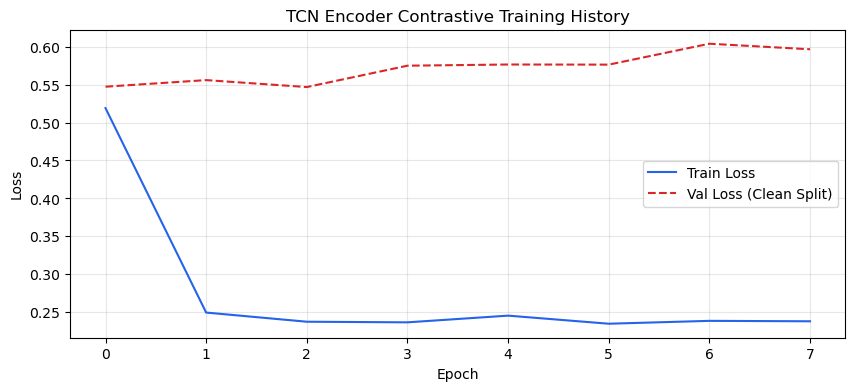

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="#2563eb", linewidth=1.5)
plt.plot(val_losses, label="Val Loss (Clean Split)", color="#dc2626", linestyle="--", linewidth=1.5)
plt.title("TCN Encoder Contrastive Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Step 5: Counterfactual Successor Memory and Scoring
We now fit the `CounterfactualSuccessorMemory` (CSM) on training windows.
The CSM stores clean historical contexts together with their successor segments.
During inference, a query context retrieves the nearest historical clean contexts. The observed suspect segment is scored against those retrieved normal successors.

We will fit the memory and query it to calculate anomaly scores on the validation and test datasets.


In [8]:
def encode_windows(model, windows, batch_size=32):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = torch.from_numpy(windows[start : start + batch_size]).float().to(device)
            embeddings.append(model(batch).cpu().numpy())
    return np.concatenate(embeddings, axis=0).astype(np.float32)

# Encode training contexts
train_contexts = train_windows[:, :context_size]
train_successors = train_windows[:, context_size:]
train_context_embeddings = encode_windows(model, train_contexts)

# Instantiate and fit successor memory
memory = CounterfactualSuccessorMemory(
    SuccessorMemoryConfig(n_neighbors=8, max_memory_windows=5000, context_percentile=99.0, seed=42)
)
memory.fit(train_context_embeddings, train_successors)
print(f"Fitted Successor Memory with {len(memory.context_embeddings)} windows.")

def compute_anomaly_scores(windows, dataset_name):
    print(f"Computing anomaly scores for {dataset_name} set...")
    
    # 1. Obtain calibration stats from training memory
    train_local_scores = local_deviation_scores(train_windows, context_size, tail_size=64)
    calibration_local_scores = train_local_scores[memory.sample_indices]
    
    successor_stats = robust_stats(memory.calibration_successor_scores)
    local_stats = robust_stats(calibration_local_scores)
    
    # 2. Query Successor Memory for the target dataset
    contexts = windows[:, :context_size]
    observed_successors = windows[:, context_size:]
    context_embeddings = encode_windows(model, contexts)
    query = memory.query(context_embeddings, observed_successors)
    
    # 3. Compute component robust Z-scores
    local_raw_scores = local_deviation_scores(windows, context_size, tail_size=64)
    successor_z = positive_robust_z(query.successor_scores, successor_stats)
    local_z = positive_robust_z(local_raw_scores, local_stats)
    
    if float(memory.context_threshold) <= 1e-6:
        context_ratio = np.ones_like(query.context_distances, dtype=np.float32)
    else:
        context_ratio = query.context_distances / float(memory.context_threshold)
        
    # 4. Fuse scores
    window_scores = fuse_evidence_scores(successor_z, local_z, context_ratio)
    return window_scores

# Compute window-level scores
val_window_scores = compute_anomaly_scores(val_windows, "Validation")
test_window_scores = compute_anomaly_scores(test_windows, "Test")


Fitted Successor Memory with 641 windows.
Computing anomaly scores for Validation set...


Computing anomaly scores for Test set...


### Step 6: Point-level Score Aggregation and Smoothing
The window-level fused anomaly scores must be mapped back to point-level scores, since anomaly labels are defined at the individual timestamp level.
We aggregate window scores back to point scores using a running mean over the suspect segment indices and then smooth the resulting score curves using a moving average window.


In [9]:
smoothing_window = 12

def process_point_scores(window_scores, raw_len):
    # Aggregate window-level scores to point-level
    point_scores, valid_mask = aggregate_window_scores(
        window_scores,
        n_points=raw_len,
        context_size=context_size,
        suspect_size=suspect_size,
        step=step,
        reducer="mean"
    )
    # Smooth point-level scores using moving average
    smoothed = moving_average(point_scores, smoothing_window)
    return smoothed, valid_mask

val_scores, val_mask = process_point_scores(val_window_scores, len(val_df))
test_scores, test_mask = process_point_scores(test_window_scores, len(test_df))

print(f"Validation point scores shape: {val_scores.shape}")
print(f"Test point scores shape:       {test_scores.shape}")


Validation point scores shape: (1008,)
Test point scores shape:       (4032,)


### Step 7: Threshold Calibration
To detect anomalies, we need to choose a decision threshold. We will compare two distinct strategies:
1. **Unsupervised Adaptive Elbow Floor (NCAD v4 default)**: Finds a threshold using the score distribution shape and consensus geometry of the validation set scores, without using any anomaly labels.
2. **Supervised Tuning on Validation set**: Tunes the threshold directly to maximize the F1-score on the labeled validation set. This serves as the upper-bound reference for validation tuning.


In [10]:
# Strategy 1: Unsupervised Adaptive Elbow Threshold
val_valid_scores = val_scores[val_mask]
floor_res = adaptive_elbow_score_floor(val_valid_scores)
unsupervised_threshold = floor_res.threshold
print(f"Unsupervised Adaptive Elbow Threshold: {unsupervised_threshold:.5f} (Selected candidate: {floor_res.selected_candidate})")

# Strategy 2: Supervised Validation Set Tuning (Maximize F1)
val_labels = val_df['is_anomaly'].to_numpy()
best_f1 = 0.0
best_threshold = 0.0

# Linearly search candidate thresholds
candidates = np.linspace(np.percentile(val_valid_scores, 50.0), np.percentile(val_valid_scores, 99.9), 300)
for th in candidates:
    preds = event_level_filter(val_scores, th, val_mask, min_run=2, extreme_factor=1.75)
    metrics = compute_metrics(val_labels, preds, valid_mask=val_mask)
    if metrics.get('f1', 0.0) > best_f1:
        best_f1 = metrics['f1']
        best_threshold = th

print(f"Supervised Validation Optimized Threshold: {best_threshold:.5f} (Validation F1-score: {best_f1:.4f})")


Unsupervised Adaptive Elbow Threshold: 1.71149 (Selected candidate: lower_elbow)


Supervised Validation Optimized Threshold: 1.95931 (Validation F1-score: 0.4476)


### Step 8: Test Set Evaluation
We evaluate both the unsupervised threshold and the validation-optimized threshold on the unseen Test dataset. We compute standard classification metrics: Precision, Recall, F1-Score, and the confusion matrix elements (TP, TN, FP, FN).


In [11]:
test_labels = test_df['is_anomaly'].to_numpy()

for name, threshold in [("Unsupervised Adaptive Elbow", unsupervised_threshold), ("Validation Set Optimized", best_threshold)]:
    # Apply event-level filtering
    preds = event_level_filter(test_scores, threshold, test_mask, min_run=2, extreme_factor=1.75)
    preds = preds * test_mask.astype(np.float32)
    
    # Compute metrics
    metrics = compute_metrics(test_labels, preds, valid_mask=test_mask)
    
    print(f"\n=== Test Set Evaluation: {name} Threshold ({threshold:.5f}) ===")
    print(f"Precision:        {metrics.get('precision', 0.0):.4f}")
    print(f"Recall:           {metrics.get('recall', 0.0):.4f}")
    print(f"F1-Score:         {metrics.get('f1', 0.0):.4f}")
    print(f"Confusion Matrix: TP={metrics.get('tp')}, TN={metrics.get('tn')}, FP={metrics.get('fp')}, FN={metrics.get('fn')}")



=== Test Set Evaluation: Unsupervised Adaptive Elbow Threshold (1.71149) ===
Precision:        0.0412
Recall:           0.9596
F1-Score:         0.0789
Confusion Matrix: TP=95, TN=1436, FP=2213, FN=4

=== Test Set Evaluation: Validation Set Optimized Threshold (1.95931) ===
Precision:        0.0475
Recall:           0.9192
F1-Score:         0.0903
Confusion Matrix: TP=91, TN=1824, FP=1825, FN=8


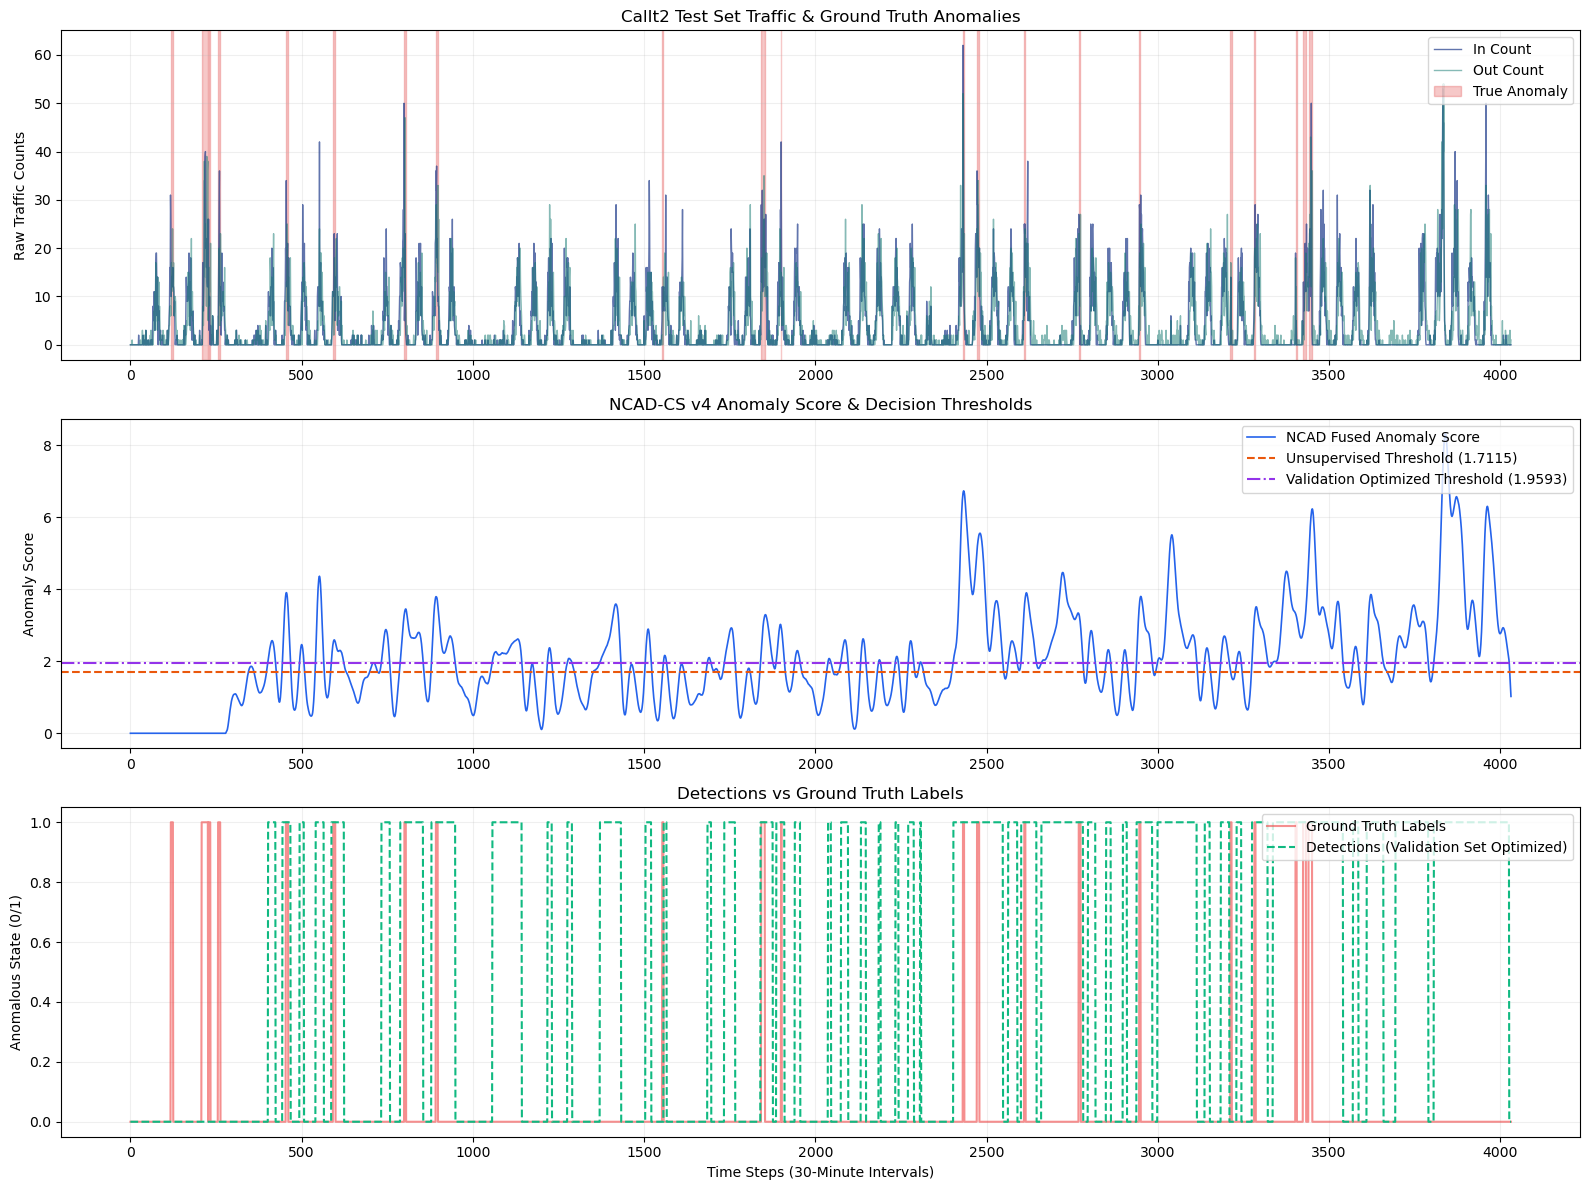

In [12]:
plt.figure(figsize=(16, 12))

# Plot 1: Input Traffic Flows & Ground Truth Anomaly Regions
plt.subplot(3, 1, 1)
plt.plot(test_df['in_count'], label="In Count", color="#1e3a8a", alpha=0.7, linewidth=1.0)
plt.plot(test_df['out_count'], label="Out Count", color="#0f766e", alpha=0.5, linewidth=1.0)

# Highlight anomaly spans
anomaly_indices = np.where(test_labels > 0)[0]
if len(anomaly_indices) > 0:
    start_idx = anomaly_indices[0]
    for i in range(1, len(anomaly_indices)):
        if anomaly_indices[i] != anomaly_indices[i-1] + 1:
            plt.axvspan(start_idx, anomaly_indices[i-1], color="#dc2626", alpha=0.25, label="True Anomaly" if start_idx == anomaly_indices[0] else "")
            start_idx = anomaly_indices[i]
    plt.axvspan(start_idx, anomaly_indices[-1], color="#dc2626", alpha=0.25)

plt.title("CalIt2 Test Set Traffic & Ground Truth Anomalies")
plt.ylabel("Raw Traffic Counts")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

# Plot 2: Anomaly Scores and Calibration Thresholds
plt.subplot(3, 1, 2)
plt.plot(test_scores, label="NCAD Fused Anomaly Score", color="#2563eb", linewidth=1.2)
plt.axhline(unsupervised_threshold, color="#ea580c", linestyle="--", label=f"Unsupervised Threshold ({unsupervised_threshold:.4f})")
plt.axhline(best_threshold, color="#9333ea", linestyle="-.", label=f"Validation Optimized Threshold ({best_threshold:.4f})")
plt.ylabel("Anomaly Score")
plt.title("NCAD-CS v4 Anomaly Score & Decision Thresholds")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

# Plot 3: Model Predictions vs Ground Truth Labels
plt.subplot(3, 1, 3)
opt_preds = event_level_filter(test_scores, best_threshold, test_mask, min_run=2, extreme_factor=1.75)
plt.plot(test_labels, label="Ground Truth Labels", color="#ef4444", linewidth=1.5, alpha=0.6)
plt.plot(opt_preds, label="Detections (Validation Set Optimized)", color="#10b981", linestyle="--", linewidth=1.5)
plt.ylabel("Anomalous State (0/1)")
plt.xlabel("Time Steps (30-Minute Intervals)")
plt.title("Detections vs Ground Truth Labels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
